In [1]:
# Import all necessary libraries for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Classifiers we will train and compare
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

# Tools for splitting data and evaluating models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

# For saving our trained models
import joblib
import os

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# Load the cleaned diabetes dataset we prepared in Phase 2
diabetes = pd.read_csv('D:/shap-reliability-research/data/diabetes_clean.csv')

# Quick confirmation
print("Diabetes dataset loaded successfully")
print("Shape:", diabetes.shape)
print("\nFirst 3 rows:")
diabetes.head(3)

Diabetes dataset loaded successfully
Shape: (768, 9)

First 3 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1


In [3]:
# Separate features (X) from target variable (y)
# X contains all columns except 'Outcome' — these are the inputs to the model
# y contains only 'Outcome' — this is what the model is trying to predict
X_diabetes = diabetes.drop(columns=['Outcome'])
y_diabetes = diabetes['Outcome']

# Split into training set (80%) and test set (20%)
# training set: what the model learns from
# test set: what we use to evaluate how well the model learned
# random_state=42 ensures we get the same split every time we run this
# stratify=y ensures both splits have the same 65/35 class ratio as the full dataset
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes, 
    test_size=0.2,      # 20% goes to test set
    random_state=42,    # fixed seed for reproducibility
    stratify=y_diabetes # maintain class balance in both splits
)

print("Diabetes dataset split successfully")
print(f"Training set: {X_train_d.shape[0]} patients")
print(f"Test set: {X_test_d.shape[0]} patients")

Diabetes dataset split successfully
Training set: 614 patients
Test set: 154 patients


In [4]:
# Scale the features using StandardScaler
# This transforms each feature to have mean=0 and standard deviation=1
# This is important because features like Insulin (range: 0-800) and 
# BloodPressure (range: 0-120) are on very different scales
# Models like Logistic Regression and SVM are sensitive to this difference
# Tree-based models (Random Forest, XGBoost) don't need scaling but it doesn't hurt them

scaler = StandardScaler()

# fit_transform on training data: learns the scale from training data then applies it
X_train_d_scaled = scaler.fit_transform(X_train_d)

# transform only on test data: applies the SAME scale learned from training data
# we never fit on test data — that would be data leakage
X_test_d_scaled = scaler.transform(X_test_d)

print("Features scaled successfully")
print(f"Mean of first feature before scaling: {X_train_d.iloc[:,0].mean():.2f}")
print(f"Mean of first feature after scaling: {X_train_d_scaled[:,0].mean():.2f}")

Features scaled successfully
Mean of first feature before scaling: 3.82
Mean of first feature after scaling: -0.00


In [5]:
# Define all four models we want to compare
# random_state=42 ensures reproducibility across all models that have randomness
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    # max_iter=1000 gives LR enough iterations to converge on this dataset
    
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    # n_estimators=100 means 100 decision trees in the forest
    
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    # verbosity=0 suppresses unnecessary output during training
    
    'SVM': SVC(random_state=42, probability=True)
    # probability=True allows us to get probability scores, needed for ROC-AUC
}

# Train each model and store results
results = {}

for name, model in models.items():
    # Train the model on scaled training data
    model.fit(X_train_d_scaled, y_train_d)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test_d_scaled)
    
    # Get probability scores for ROC-AUC calculation
    # [:, 1] gets the probability of the positive class (diabetic)
    y_prob = model.predict_proba(X_test_d_scaled)[:, 1]
    
    # Calculate all evaluation metrics
    results[name] = {
        'Accuracy':  accuracy_score(y_test_d, y_pred),
        'Precision': precision_score(y_test_d, y_pred),
        'Recall':    recall_score(y_test_d, y_pred),
        'F1 Score':  f1_score(y_test_d, y_pred),
        'ROC-AUC':   roc_auc_score(y_test_d, y_prob)
    }
    
    print(f"{name} trained successfully")

print("\nAll models trained")

Logistic Regression trained successfully
Random Forest trained successfully
XGBoost trained successfully
SVM trained successfully

All models trained


D:\shap-reliability-research\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [6]:
# Convert results dictionary to a DataFrame for clean display
# round to 4 decimal places for readability
results_df = pd.DataFrame(results).T.round(4)

# Sort by F1 Score — best overall metric for imbalanced datasets
results_df = results_df.sort_values('F1 Score', ascending=False)

print("========== DIABETES MODEL COMPARISON ==========")
print(results_df.to_string())

========== DIABETES MODEL COMPARISON ==========
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Random Forest          0.7597     0.6809  0.5926    0.6337   0.8200
XGBoost                0.7338     0.6275  0.5926    0.6095   0.8096
SVM                    0.7338     0.6444  0.5370    0.5859   0.7939
Logistic Regression    0.7078     0.6000  0.5000    0.5455   0.8152


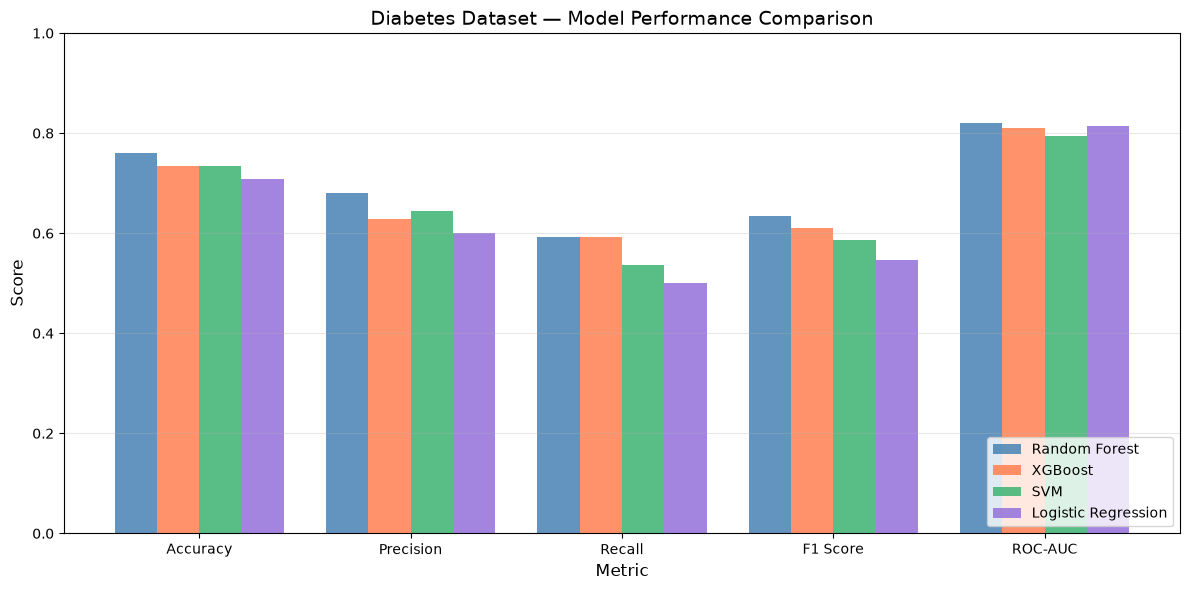

Chart saved to results/figures/


In [7]:
# Plot model comparison as a grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Set up bar positions
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))  # position of each metric group on x-axis
width = 0.2  # width of each individual bar
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

# Plot one set of bars per model
for i, (model_name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width,           # shift each model's bars to the right
           [row[m] for m in metrics], # the actual metric values
           width,                     # bar width
           label=model_name,          # for the legend
           color=colors[i],           # assign a color per model
           alpha=0.85)                # slight transparency

# Labels and formatting
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Diabetes Dataset — Model Performance Comparison', fontsize=14)
ax.set_xticks(x + width * 1.5)   # center the tick labels under each group
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)              # all metrics are between 0 and 1
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)    # light horizontal gridlines for readability

plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/diabetes_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to results/figures/")

In [8]:
# Save the results table to a CSV file
# so we have a permanent record of model performance
results_df.to_csv('D:/shap-reliability-research/results/tables/diabetes_model_comparison.csv')
print("Results table saved successfully")

Results table saved successfully


In [9]:
# Detailed breakdown of Random Forest performance
# retrain predictions for the report
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test_d_scaled)

print("=== RANDOM FOREST — DETAILED REPORT ===")
print(classification_report(y_test_d, y_pred_rf, 
                            target_names=['Not Diabetic', 'Diabetic']))

=== RANDOM FOREST — DETAILED REPORT ===
              precision    recall  f1-score   support

Not Diabetic       0.79      0.85      0.82       100
    Diabetic       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



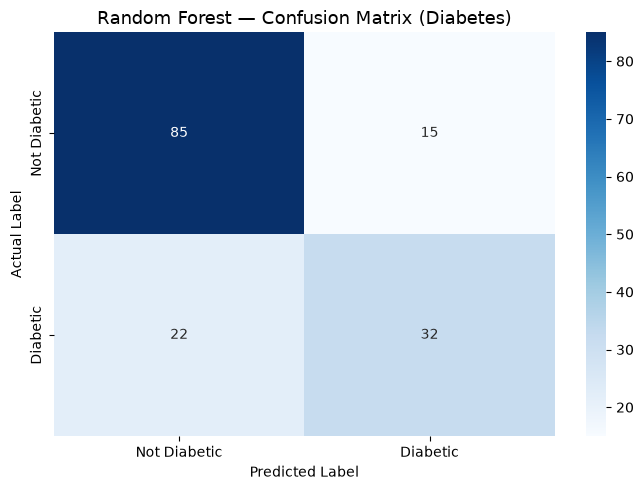

Confusion matrix saved


In [10]:
# Confusion matrix shows exactly how many patients were correctly
# and incorrectly classified in each category
cm = confusion_matrix(y_test_d, y_pred_rf)

plt.figure(figsize=(7, 5))

# sns.heatmap draws the matrix as a colour-coded grid
# annot=True writes the numbers inside each cell
# fmt='d' displays them as integers not decimals
# cmap='Blues' uses a blue colour scale
sns.heatmap(cm, 
            annot=True,        # show numbers inside each cell
            fmt='d',           # format as integers
            cmap='Blues',      # blue color scheme
            xticklabels=['Not Diabetic', 'Diabetic'],   # predicted labels
            yticklabels=['Not Diabetic', 'Diabetic'])   # actual labels

plt.title('Random Forest — Confusion Matrix (Diabetes)', fontsize=13)
plt.ylabel('Actual Label')     # rows = what the patient actually is
plt.xlabel('Predicted Label')  # columns = what the model predicted

plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/diabetes_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")

In [11]:
# Load the cleaned CKD dataset
ckd = pd.read_csv('D:/shap-reliability-research/data/ckd_clean.csv')

# Separate features from target variable
# 'classification' is our target: 1 = CKD, 0 = not CKD
X_ckd = ckd.drop(columns=['classification'])
y_ckd = ckd['classification']

# Split into training (80%) and test (20%) sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_ckd, y_ckd,
    test_size=0.2,
    random_state=42,
    stratify=y_ckd  # maintain class ratio in both splits
)

# Scale the features using a fresh scaler for the CKD dataset
scaler_ckd = StandardScaler()
X_train_c_scaled = scaler_ckd.fit_transform(X_train_c)
X_test_c_scaled = scaler_ckd.transform(X_test_c)

print("CKD dataset loaded and split successfully")
print(f"Training set: {X_train_c.shape[0]} patients")
print(f"Test set: {X_test_c.shape[0]} patients")

CKD dataset loaded and split successfully
Training set: 320 patients
Test set: 80 patients


In [12]:
# Train the same four models on the CKD dataset
# We reuse the same model definitions for consistency
ckd_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    'SVM': SVC(random_state=42, probability=True)
}

# Train each model and store results
ckd_results = {}

for name, model in ckd_models.items():
    # Train on scaled CKD training data
    model.fit(X_train_c_scaled, y_train_c)
    
    # Predict on test set
    y_pred = model.predict(X_test_c_scaled)
    
    # Get probability scores for ROC-AUC
    y_prob = model.predict_proba(X_test_c_scaled)[:, 1]
    
    # Calculate evaluation metrics
    ckd_results[name] = {
        'Accuracy':  accuracy_score(y_test_c, y_pred),
        'Precision': precision_score(y_test_c, y_pred),
        'Recall':    recall_score(y_test_c, y_pred),
        'F1 Score':  f1_score(y_test_c, y_pred),
        'ROC-AUC':   roc_auc_score(y_test_c, y_prob)
    }
    
    print(f"{name} trained successfully")

print("\nAll CKD models trained")

Logistic Regression trained successfully
Random Forest trained successfully
XGBoost trained successfully
SVM trained successfully

All CKD models trained


D:\shap-reliability-research\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [13]:
# Convert results to DataFrame and sort by F1 Score
ckd_results_df = pd.DataFrame(ckd_results).T.round(4)
ckd_results_df = ckd_results_df.sort_values('F1 Score', ascending=False)

print("=== CKD MODEL COMPARISON ===")
print(ckd_results_df.to_string())

=== CKD MODEL COMPARISON ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
SVM                    1.0000     1.0000  1.0000    1.0000   1.0000
Logistic Regression    0.9875     0.9677  1.0000    0.9836   1.0000
Random Forest          0.9750     1.0000  0.9333    0.9655   0.9993
XGBoost                0.9625     1.0000  0.9000    0.9474   0.9973


In [14]:
# Check the detailed report for SVM on CKD
svm_ckd = ckd_models['SVM']
y_pred_svm = svm_ckd.predict(X_test_c_scaled)

print("=== SVM — DETAILED REPORT (CKD) ===")
print(classification_report(y_test_c, y_pred_svm,
                            target_names=['Not CKD', 'CKD']))

# Also check the confusion matrix numbers
cm_ckd = confusion_matrix(y_test_c, y_pred_svm)
print("\nConfusion Matrix:")
print(cm_ckd)

# Check class distribution in test set
print("\nTest set class distribution:")
print(y_test_c.value_counts())

=== SVM — DETAILED REPORT (CKD) ===
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        50
         CKD       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Confusion Matrix:
[[50  0]
 [ 0 30]]

Test set class distribution:
classification
0    50
1    30
Name: count, dtype: int64


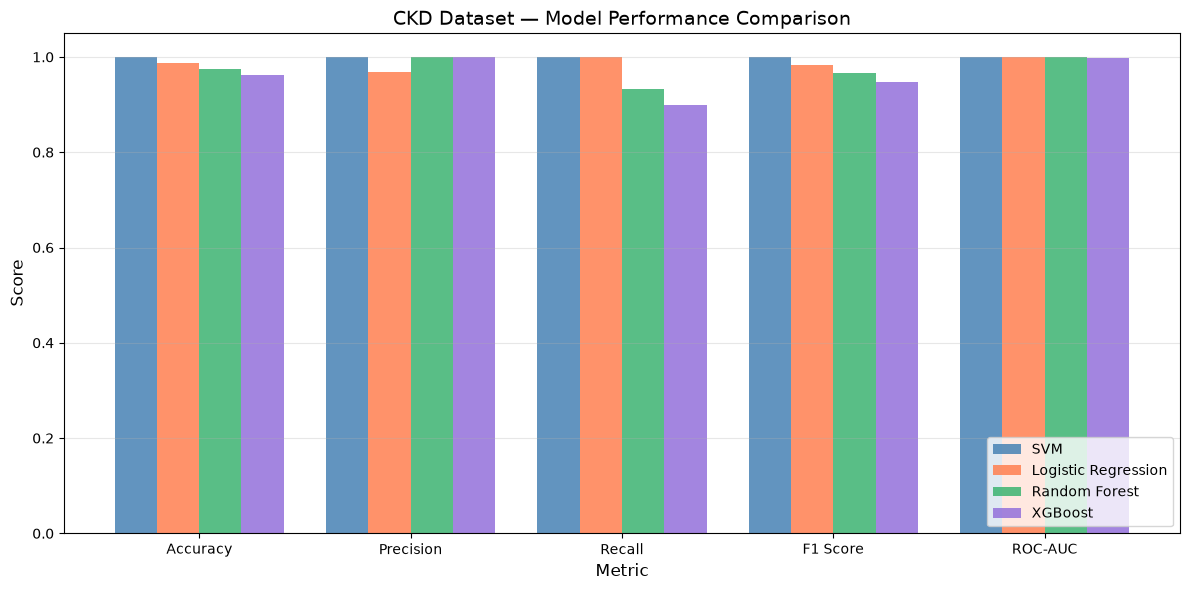

CKD results saved successfully
CKD Random Forest model saved
CKD scaler saved


In [18]:
# Save CKD results table
ckd_results_df.to_csv('D:/shap-reliability-research/results/tables/ckd_model_comparison.csv')

# Plot CKD model comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for i, (model_name, row) in enumerate(ckd_results_df.iterrows()):
    ax.bar(x + i * width,
           [row[m] for m in metrics],
           width,
           label=model_name,
           color=colors[i],
           alpha=0.85)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('CKD Dataset — Model Performance Comparison', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/ckd_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save the best CKD model (Random Forest — more trustworthy than perfect SVM)
# We deliberately choose Random Forest over SVM here because:
# 1. Perfect scores warrant caution
# 2. Random Forest is more interpretable with SHAP
# 3. Random Forest's 0.9655 F1 is still excellent and more believable


# Create the models folder if it doesn't exist
os.makedirs('D:/shap-reliability-research/models', exist_ok=True)

joblib.dump(ckd_models['Random Forest'], 
            'D:/shap-reliability-research/models/ckd_rf_model.pkl')
joblib.dump(scaler_ckd, 
            'D:/shap-reliability-research/models/ckd_scaler.pkl')

print("CKD results saved successfully")
print("CKD Random Forest model saved")
print("CKD scaler saved")

In [20]:
 # Save diabetes models
joblib.dump(models['Random Forest'], 
            'D:/shap-reliability-research/models/diabetes_rf_model.pkl')
joblib.dump(scaler, 
            'D:/shap-reliability-research/models/diabetes_scaler.pkl')

print("All models saved successfully")

# Confirm all files exist
print("\nFiles in models folder:")
for f in os.listdir('D:/shap-reliability-research/models/'):
    print(" -", f)

All models saved successfully

Files in models folder:
 - ckd_rf_model.pkl
 - ckd_scaler.pkl
 - diabetes_rf_model.pkl
 - diabetes_scaler.pkl
